In [1]:
import matplotlib.pyplot as plt
import numpy as np

<h2>A simple example</h2>

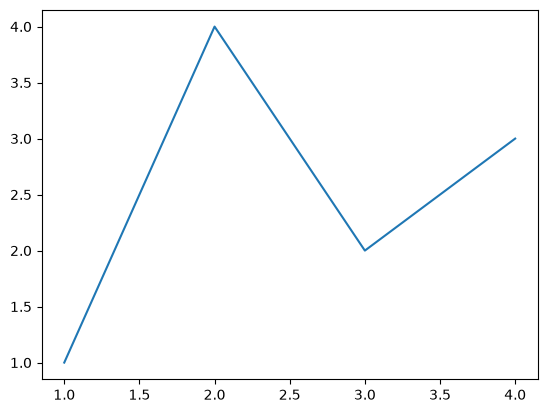

In [2]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4],[1, 4, 2, 3])
#plt.show()

<h4>Figure</h4>

Typically, you'll create a new Figure through one of the following functions:

<Figure size 640x480 with 0 Axes>

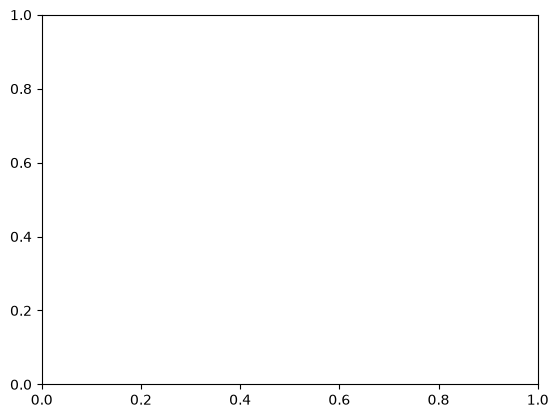

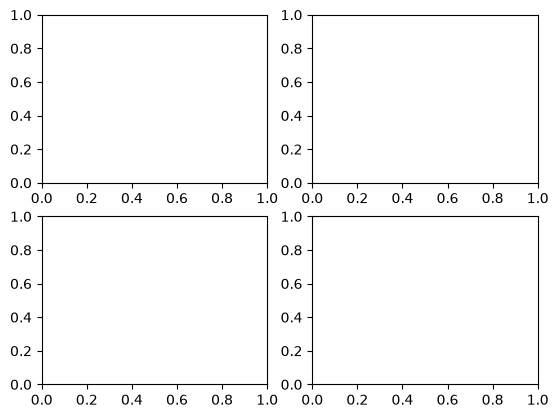

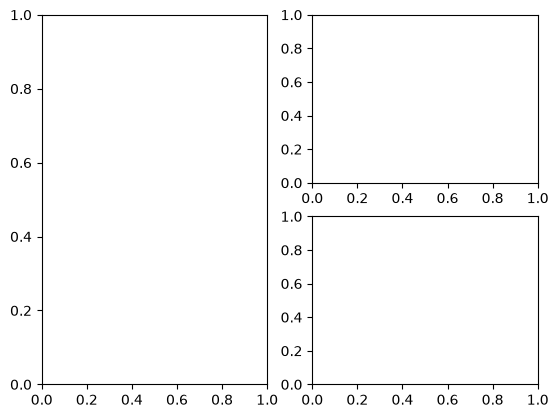

In [3]:
fig = plt.figure() #an empty figure with no Axes
fig, ax = plt.subplots() #a figure with a single Axes
fig, axs = plt.subplots(2,2) # A figure with a 2x2 grid of Axes
fig, axs = plt.subplot_mosaic([['left', 'right_top'],
                               ['left', 'right_bottom']])

<h4>Types of inputs to plotting functions</h4>

Plotting functions expect numpy.array or numpy.ma.masked_array as input, or objects that can be passed to numpy.asarray. Classes that are similar to arrays ('array-like') such as pandas data objects and numpy.matrix may not work as intended. Common convention is to convert these to numpy.array objects prior to plotting. For example, to convert a numpy.matrix

In [4]:
b = np.matrix([[1,2],[3, 4]])
b_asarray = np.asarray(b)
b_asarray

array([[1, 2],
       [3, 4]])

Most methods will also parse a string-indexable object like a dict, a structured numpy array, or a pandas.DataFrame. Matplotlib allows you to provide the data keyword argument and generate plots passing the strings corresponding to the x and y variables.

Text(0, 0.5, 'entry b')

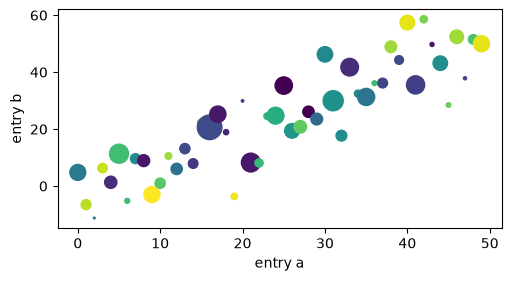

In [5]:
np.random.seed(19680801)  # seed the random number generator.
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)}
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
ax.scatter('a', 'b', c='c', s='d', data=data)
ax.set_xlabel('entry a')
ax.set_ylabel('entry b')

<h2>Coding styles</h2>

There are essentially two ways to use Matplotlib:<br>
Explicitly create Figures and Axes, and call methods on them (the "object-oriented (OO) style").<br/>
Rely on pyplot to implicitly create and manage the Figures and Axes, and use pyplot functions for plotting.

OO-Style

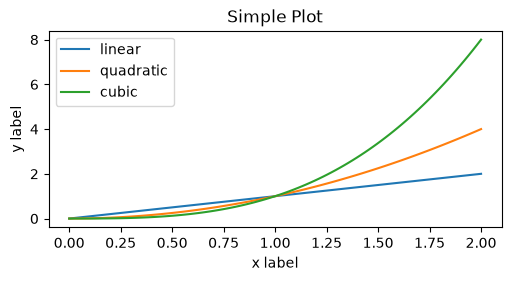

In [6]:
x = np.linspace(0, 2, 100)

# Note that even in the OO-style, we use `.pyplot.figure` to create the Figure.
fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
ax.plot(x, x, label ='linear')
ax.plot(x, x**2, label='quadratic')
ax.plot(x, x**3, label='cubic')
ax.set_xlabel('x label')
ax.set_ylabel('y label')
ax.set_title('Simple Plot')
ax.legend()

the pyplot style

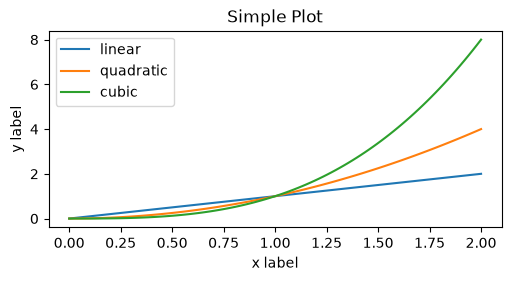

In [7]:
x = np.linspace(0, 2, 100)

plt.figure(figsize=(5, 2.7), layout='constrained')
plt.plot(x, x, label ='linear')
plt.plot(x, x**2, label='quadratic')
plt.plot(x, x**3, label='cubic')
plt.xlabel('x label')
plt.ylabel('y label')
plt.title('Simple Plot')
plt.legend()

<h2>Making a helper function</h2>

In [8]:
def my_plotter(ax, data1, data2, param_dict):
    out = ax.plot(data1, data2, **param_dict)
    return out

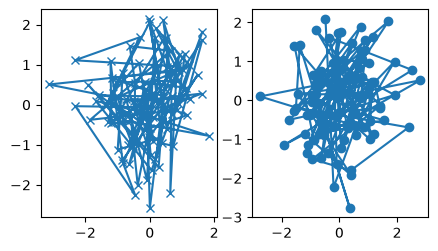

In [9]:
data1, data2, data3, data4 = np.random.randn(4, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2.7))
my_plotter(ax1, data1, data2, {'marker':'x'})
my_plotter(ax2, data3, data4, {'marker':'o'})

<h2>Styling Artists</h2>

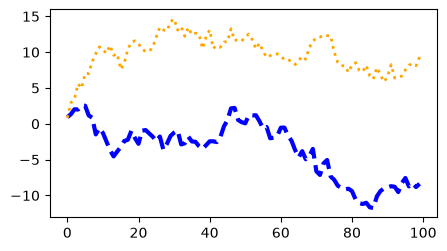

In [10]:
fig, ax = plt.subplots(figsize=(5, 2.7))
x = np.arange(len(data1))
ax.plot(x, np.cumsum(data1), color ='blue', linewidth=3,linestyle='--')
l, = ax.plot(x, np.cumsum(data2), color='orange', linewidth =2)
l.set_linestyle(':')

<h2>Colors</h2>

Matplotlib has a very flexible array of colors that are accepted for most Artists; see allowable color definitions for a list of specifications. Some Artists will take multiple colors. i.e. for a scatter plot, the edge of the markers can be different colors from the interior:

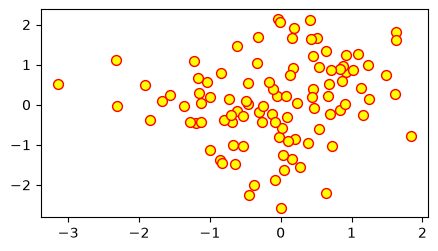

In [11]:
fig, ax = plt.subplots(figsize=(5, 2.7))
ax.scatter(data1,data2, s=50, facecolor='yellow', edgecolor='red')
#ax.scatter(data1, data2, s=50, facecolor='C0', edgecolor='k')

<h2>Linewidths, linestyles and markersizes</h2>

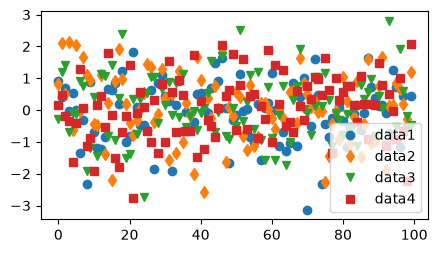

In [12]:
fig, ax = plt.subplots(figsize=(5, 2.7))
ax.plot(data1, 'o', label='data1')
ax.plot(data2, 'd', label='data2')
ax.plot(data3, 'v', label='data3')
ax.plot(data4, 's', label='data4')
ax.legend()

<h2>Labelling plots</h2>

<h4>Axes, labels and text</h4>

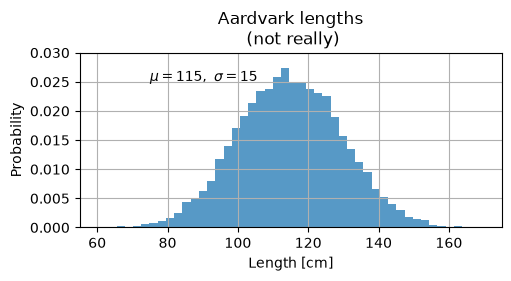

In [13]:
mu, sigma = 115, 15
x = mu + sigma * np.random.randn(10000)
fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
# the histogram of the data
n, bins, patches = ax.hist(x, 50, density=True, facecolor='C0', alpha=0.75)

ax.set_xlabel('Length [cm]')
ax.set_ylabel('Probability')
ax.set_title('Aardvark lengths\n (not really)')
ax.text(75, .025, r'$\mu=115,\ \sigma=15$')
ax.axis([55, 175, 0, 0.03])
ax.grid(True)

<h4>Using mathematical expressions in text</h4>

Matplotlib accepts TeX equation expressions in any text expression. For example to write the expression 𝜎𝑖 =15 in the title, you can write a TeX expression surrounded by dollar signs:
ax.set_title(r'$\sigma_i=15$')
where the r preceding the title string signifies that the string is a raw string and not to treat backslashes as python escapes. Matplotlib has a built-in TeX expression parser and layout engine, and ships its own math fonts – for details see Writing mathematical expressions. You can also use LaTeX directly to format your text and incorporate the output directly into your display figures or saved postscript – see Text rendering with LaTeX.




<h4>Annotations</h4>

We can also annotate points on a plot, often by connecting an arrow pointing to xy, to a piece of text at xytext:

(-2.0, 2.0)

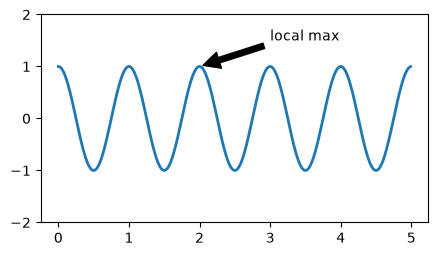

In [14]:
fix, ax = plt.subplots(figsize=(5, 2.7))
t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2 * np.pi *t)
line, = ax.plot(t,s, lw=2)
ax.annotate('local max', xy=(2, 1), xytext=(3, 1.5),
           arrowprops=dict(facecolor='black', shrink=0.05))
ax.set_ylim(-2, 2)

<h4>Legends</h4>
Often we want to identify lines or markers with a Axes.legend:

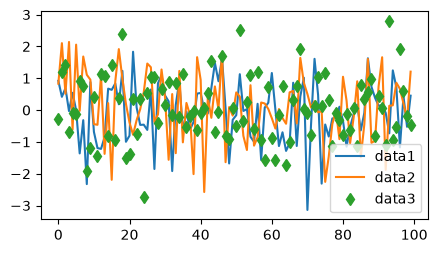

In [15]:
fig, ax = plt.subplots(figsize=(5, 2.7))
ax.plot(np.arange(len(data1)), data1, label='data1')
ax.plot(np.arange(len(data2)), data2, label='data2')
ax.plot(np.arange(len(data3)), data3,'d', label='data3')
ax.legend()

<h2>Axis scales and ticks</h2>

Each Axes has two (or three) Axis objects representing the x- and y-axis. These control the scale of the Axis, the tick locators and the tick formatters. Additional Axes can be attached to display further Axis objects.

<h4>Scales</h4>
In addition to the linear scale, Matplotlib supplies non-linear scales, such as a log-scale. Since log-scales are used so much there are also direct methods like loglog, semilogx, and semilogy. There are a number of scales (see Scales overview for other examples). Here we set the scale manually:


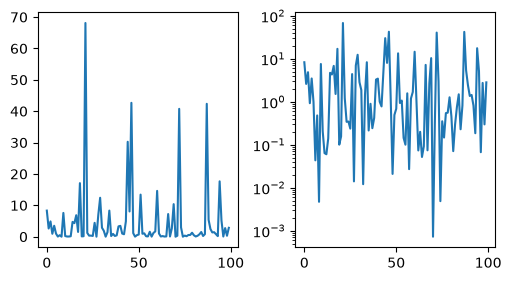

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(5, 2.7), layout='constrained')
xdata= np.arange(len(data1))
data = 10**data1

axs[0].plot(xdata, data)

axs[1].set_yscale('log')
axs[1].plot(xdata, data)

<h4>Tick locators and formatters</h4>
Each Axis has a tick locator and formatter that choose where along the Axis objects to put tick marks. A simple interface to this is set_xticks:

Text(0.5, 1.0, 'Manual ticks')

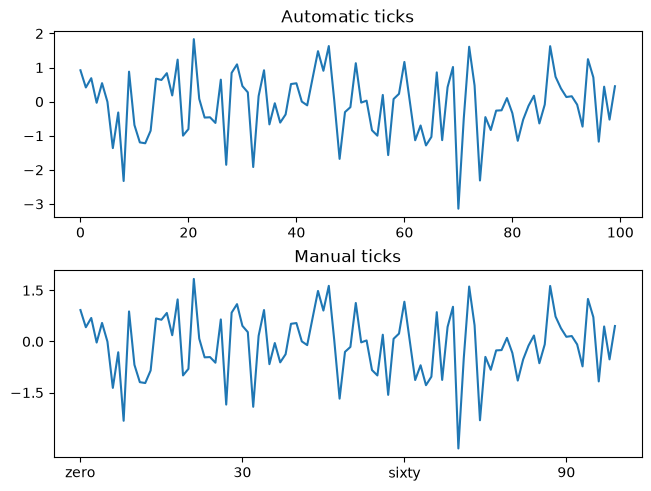

In [17]:
fig, axs = plt.subplots(2, 1, layout='constrained')
axs[0].plot(xdata, data1)
axs[0].set_title('Automatic ticks')

axs[1].plot(xdata, data1)
axs[1].set_xticks(np.arange(0, 100, 30),['zero','30','sixty','90'])
axs[1].set_yticks([-1.5, 0, 1.5]) # we don't need to specify labels
axs[1].set_title('Manual ticks')

<h2>Plotting dates and strings</h2>
Demo of ConciseDateFormatter

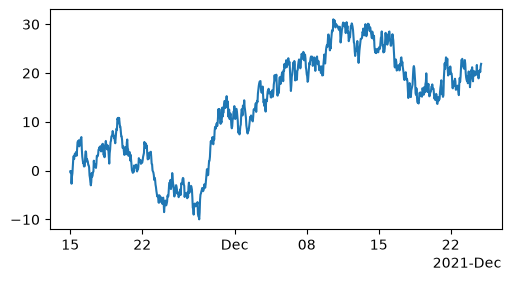

In [18]:
from matplotlib.dates import ConciseDateFormatter

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
dates = np.arange(np.datetime64('2021-11-15'),np.datetime64('2021-12-25'),
                  np.timedelta64(1,'h'))
data=np.cumsum(np.random.randn(len(dates)))
ax.plot(dates, data)
ax.xaxis.set_major_formatter(ConciseDateFormatter(ax.xaxis.get_major_locator()))

For strings, we get categorical plotting

<h2>Additional Axis objects</h2>

Plotting data of different magnitude in one chart may require an additional y-axis. Such an Axis can be created by using twinx to add a new Axes with an invisible x-axis and a y-axis positioned at the right (analogously for twiny). See Plots with different scales for another example.

Similarly, you can add a secondary_xaxis or secondary_yaxis having a different scale than the main Axis to represent the data in different scales or units. See Secondary Axis for further examples.

/tmp/ipykernel_31335/2514111319.py:5: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax2.legend([l1,l2],['Sine(left)','Straight (right)'])


Text(0.5, 0, 'Angle[*]')

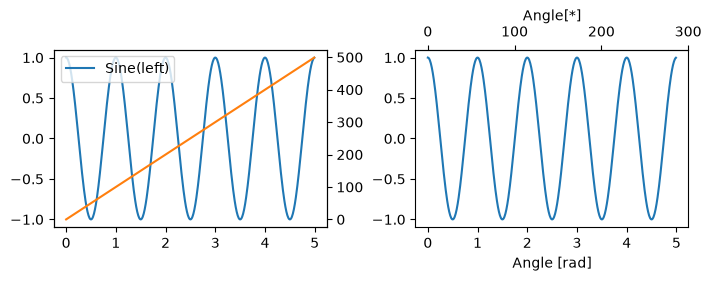

In [19]:
fig, (ax1, ax3) = plt.subplots(1,2,figsize=(7, 2.7),layout='constrained')
l1, = ax1.plot(t,s)
ax2 = ax1.twinx()
l2 = ax2.plot(t, range(len(t)), 'C1')
ax2.legend([l1,l2],['Sine(left)','Straight (right)'])

ax3.plot(t, s)
ax3.set_xlabel('Angle [rad]')
ax4 = ax3.secondary_xaxis('top',(np.rad2deg, np.deg2rad))
ax4.set_xlabel('Angle[*]')
              

<h2>Color mapped data</h2>
Often we want to have a third dimension in a plot represented by colors in a colormap. Matplotlib has a number of plot types that do this:

Text(0.5, 1.0, 'scatter()')

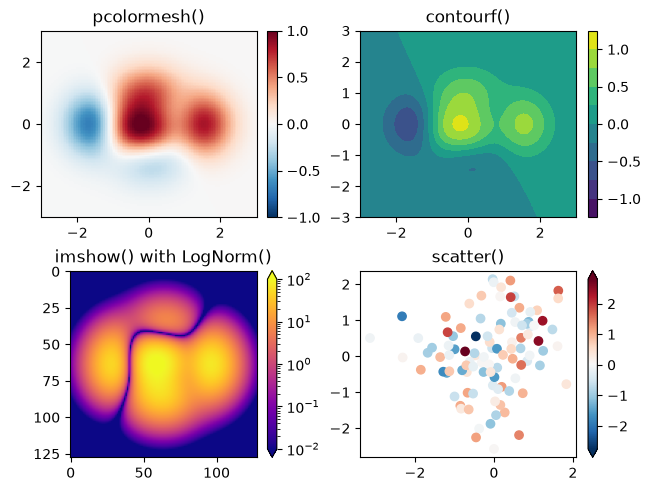

In [20]:
from matplotlib.colors import LogNorm

X,Y = np.meshgrid(np.linspace(-3, 3, 128), np.linspace(-3, 3, 128))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)

fig, axs = plt.subplots(2, 2, layout='constrained')
pc = axs[0,0].pcolormesh(X,Y,Z, vmin = -1, vmax = 1, cmap='RdBu_r')
fig.colorbar(pc, ax=axs[0,0])
axs[0,0].set_title('pcolormesh()')

co = axs[0,1].contourf(X,Y,Z, levels = np.linspace(-1.25, 1.25, 11))
fig.colorbar(co, ax=axs[0,1])
axs[0,1].set_title('contourf()')

pc = axs[1,0].imshow(Z**2 * 100, cmap='plasma', norm=LogNorm(vmin=0.01, vmax=100))
fig.colorbar(pc, ax=axs[1,0], extend='both')
axs[1,0].set_title('imshow() with LogNorm()')

pc = axs[1,1].scatter(data1, data2, c=data3, cmap='RdBu_r')
fig.colorbar(pc, ax=axs[1,1], extend='both')
axs[1,1].set_title('scatter()')

<h2>Colormaps</h2>

See file ChoosingColormapsInMatplotlib in misc folder

<h2>Normalizations</h2>
 See file ColormapNormalization in misc folder

<h2>Colorbars</h2>

See file PlacingColorbars in misc folder